# Simulação térmica didática com rampa de temperatura e animação

Esta versão adiciona duas coisas ao notebook anterior:

- **rampa de temperatura** de **1 K até 10000 K** ao longo da simulação;
- **animação da trajetória** molecular.

A dinâmica continua sendo uma **MD didática**: há massas, velocidades, forças, integração temporal e um termostato simples.  
A simulação **para automaticamente** quando uma ligação excede o critério geométrico de quebra:

\[
d_{ij} > f_{\mathrm{break}}\,(r_i^{\mathrm{cov}} + r_j^{\mathrm{cov}})
\]

> **Importante**  
> Isto ainda **não** é dinâmica reativa quantitativa. A quebra é detectada por critério geométrico, o que é adequado para fins didáticos.


In [ ]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 24.8 MB/s eta 0:00:00


In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

from rdkit import Chem
from rdkit.Chem import AllChem, Draw


In [ ]:
# =========================
# Escolha da molécula
# =========================
smiles = "C1=CC=CC=C1"   # benzeno (teste)

# Rampa térmica
temperature_start = 1.0      # K
temperature_end = 10000.0    # K

# Parâmetros numéricos da dinâmica
n_steps = 12000
dt = 2.5e-4                  # passo de tempo em unidades internas
thermostat_tau = 0.03        # acoplamento do termostato
break_factor = 2.0           # quebra se d_ij > break_factor * (r_cov_i + r_cov_j)
break_persistence = 20       # número de passos consecutivos para confirmar a quebra
save_every = 10              # salvar um frame da trajetória a cada N passos

# Dica:
# - Se quebrar cedo demais, aumente break_factor ou diminua dt.
# - Se não quebrar nunca, aumente n_steps, diminua break_factor ou aumente temperature_end.


In [ ]:
# =========================
# Construção da molécula e utilidades
# =========================
def build_molecule(smiles: str, seed: int = 0xF00D):
    mol = Chem.AddHs(Chem.MolFromSmiles(smiles))
    if mol is None:
        raise ValueError("SMILES inválido.")
    status = AllChem.EmbedMolecule(mol, randomSeed=seed)
    if status != 0:
        raise RuntimeError("Falha ao gerar geometria 3D com RDKit.")
    AllChem.UFFOptimizeMolecule(mol)
    return mol

def get_positions(mol):
    conf = mol.GetConformer()
    return np.array([
        [conf.GetAtomPosition(i).x, conf.GetAtomPosition(i).y, conf.GetAtomPosition(i).z]
        for i in range(mol.GetNumAtoms())
    ], dtype=float)

def set_positions(mol, pos):
    conf = mol.GetConformer()
    for i, p in enumerate(pos):
        conf.SetAtomPosition(i, p)

def build_topology(mol):
    conf = mol.GetConformer()
    pt = Chem.GetPeriodicTable()

    atoms = [mol.GetAtomWithIdx(i) for i in range(mol.GetNumAtoms())]
    masses = np.array([a.GetMass() for a in atoms], dtype=float)
    radii = np.array([pt.GetRcovalent(a.GetAtomicNum()) for a in atoms], dtype=float)
    symbols = [a.GetSymbol() for a in atoms]

    pos = np.array([
        [conf.GetAtomPosition(i).x, conf.GetAtomPosition(i).y, conf.GetAtomPosition(i).z]
        for i in range(mol.GetNumAtoms())
    ], dtype=float)

    bond_k_map = {
        Chem.rdchem.BondType.SINGLE:   300.0,
        Chem.rdchem.BondType.DOUBLE:   500.0,
        Chem.rdchem.BondType.TRIPLE:   700.0,
        Chem.rdchem.BondType.AROMATIC: 450.0,
    }

    bonds = []
    neighbors = {i: set() for i in range(mol.GetNumAtoms())}

    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        r0 = np.linalg.norm(pos[j] - pos[i])
        k = bond_k_map.get(bond.GetBondType(), 300.0)
        bonds.append((i, j, r0, k))
        neighbors[i].add(j)
        neighbors[j].add(i)

    one_three = set()
    for center in range(mol.GetNumAtoms()):
        nbrs = sorted(neighbors[center])
        for a in range(len(nbrs)):
            for b in range(a + 1, len(nbrs)):
                one_three.add(tuple(sorted((nbrs[a], nbrs[b]))))

    return pos, masses, radii, symbols, bonds, neighbors, one_three

EPSILON_MAP = {
    "H": 0.02,
    "C": 0.08,
    "N": 0.10,
    "O": 0.12,
    "S": 0.15,
    "F": 0.10,
    "Cl": 0.15,
    "Br": 0.20,
    "I": 0.25,
}

ATOM_SIZE_MAP = {
    "H": 80,
    "C": 140,
    "N": 170,
    "O": 170,
    "F": 170,
    "S": 210,
    "Cl": 220,
    "Br": 240,
    "I": 260,
}

ATOM_COLOR_MAP = {
    "H": "lightgray",
    "C": "black",
    "N": "royalblue",
    "O": "crimson",
    "F": "limegreen",
    "S": "goldenrod",
    "Cl": "green",
    "Br": "brown",
    "I": "purple",
}

def lj_params(symbol_i, symbol_j, radius_i, radius_j):
    sigma = 0.85 * (radius_i + radius_j)
    epsilon = math.sqrt(EPSILON_MAP.get(symbol_i, 0.08) * EPSILON_MAP.get(symbol_j, 0.08))
    return sigma, epsilon

def initialize_velocities(masses, temperature, seed=123):
    rng = np.random.default_rng(seed)
    vel = rng.normal(size=(len(masses), 3)) * np.sqrt(0.05 * max(temperature, 1e-6) / masses)[:, None]
    vel -= np.average(vel, axis=0, weights=masses)
    return vel

def kinetic_temperature(vel, masses):
    kinetic = 0.5 * np.sum(masses[:, None] * vel * vel)
    dof = max(1, 3 * len(masses) - 3)
    temperature = 2.0 * kinetic / dof
    return temperature, kinetic

def target_temperature_ramp(step, n_steps, t0, t1):
    if n_steps <= 1:
        return t1
    return t0 + (t1 - t0) * step / (n_steps - 1)


In [ ]:
# =========================
# Campo de força didático
# =========================
def forces_and_energy(pos, radii, symbols, bonds, one_three):
    n = len(pos)
    forces = np.zeros_like(pos)
    energy = 0.0

    bonded_pairs = {tuple(sorted((i, j))) for i, j, _, _ in bonds}

    # 1) Ligações harmônicas
    for i, j, r0, k in bonds:
        rij = pos[j] - pos[i]
        r = np.linalg.norm(rij) + 1e-12
        dr = r - r0

        fij = k * dr * rij / r
        forces[i] += fij
        forces[j] -= fij
        energy += 0.5 * k * dr * dr

    # 2) Repulsão não ligante tipo WCA (LJ truncado no mínimo)
    for i in range(n):
        for j in range(i + 1, n):
            pair = (i, j)
            if pair in bonded_pairs or pair in one_three:
                continue

            rij = pos[j] - pos[i]
            r = np.linalg.norm(rij) + 1e-12
            sigma, epsilon = lj_params(symbols[i], symbols[j], radii[i], radii[j])

            r_cut = 2 ** (1 / 6) * sigma
            if r < r_cut:
                sr6 = (sigma / r) ** 6
                sr12 = sr6 * sr6

                energy += 4 * epsilon * (sr12 - sr6) + epsilon
                f_mag = 24 * epsilon / r * (2 * sr12 - sr6)
                fij = f_mag * rij / r
                forces[i] -= fij
                forces[j] += fij

    return forces, energy

def detect_broken_bonds(pos, bonds, radii, factor=2.0):
    broken = []
    for bond_index, (i, j, r0, k) in enumerate(bonds):
        distance = np.linalg.norm(pos[i] - pos[j])
        threshold = factor * (radii[i] + radii[j])
        if distance > threshold:
            broken.append({
                "bond_index": bond_index,
                "i": i,
                "j": j,
                "distance": distance,
                "threshold": threshold,
                "equilibrium_distance": r0,
            })
    return broken


In [ ]:
# =========================
# Dinâmica molecular didática com rampa de temperatura
# =========================
def run_didactic_md_with_ramp(
    smiles,
    temperature_start=1.0,
    temperature_end=10000.0,
    n_steps=12000,
    dt=2.5e-4,
    thermostat_tau=0.03,
    break_factor=2.0,
    break_persistence=20,
    save_every=10,
):
    mol = build_molecule(smiles)

    pos, masses, radii, symbols, bonds, neighbors, one_three = build_topology(mol)
    vel = initialize_velocities(masses, temperature_start)

    forces, potential = forces_and_energy(pos, radii, symbols, bonds, one_three)

    trajectory = [pos.copy()]
    temperatures = []
    target_temperatures = []
    kinetic_energies = []
    potential_energies = []
    total_energies = []
    broken_history = []
    saved_steps = [0]

    persistent_counter = {idx: 0 for idx in range(len(bonds))}

    for step in range(n_steps):
        target_T = target_temperature_ramp(step, n_steps, temperature_start, temperature_end)

        # Velocity Verlet
        pos = pos + vel * dt + 0.5 * (forces / masses[:, None]) * dt * dt
        new_forces, potential = forces_and_energy(pos, radii, symbols, bonds, one_three)
        vel = vel + 0.5 * (forces + new_forces) / masses[:, None] * dt
        forces = new_forces

        # Termostato de Berendsen simples, agora seguindo a rampa alvo
        current_temperature, kinetic = kinetic_temperature(vel, masses)
        if current_temperature > 1e-12:
            scale_argument = 1.0 + dt / thermostat_tau * (target_T / current_temperature - 1.0)
            scale = math.sqrt(max(0.0, scale_argument))
            vel *= scale
            current_temperature, kinetic = kinetic_temperature(vel, masses)

        temperatures.append(current_temperature)
        target_temperatures.append(target_T)
        kinetic_energies.append(kinetic)
        potential_energies.append(potential)
        total_energies.append(kinetic + potential)

        currently_broken = detect_broken_bonds(pos, bonds, radii, factor=break_factor)
        broken_history.append(currently_broken)

        active_indices = {entry["bond_index"] for entry in currently_broken}
        persistent_broken = []
        for idx in persistent_counter:
            if idx in active_indices:
                persistent_counter[idx] += 1
            else:
                persistent_counter[idx] = 0

        for entry in currently_broken:
            if persistent_counter[entry["bond_index"]] >= break_persistence:
                persistent_broken.append(entry)

        if (step + 1) % save_every == 0:
            trajectory.append(pos.copy())
            saved_steps.append(step + 1)

        if persistent_broken:
            set_positions(mol, pos)
            # garante que o último frame exista na trajetória
            if saved_steps[-1] != step + 1:
                trajectory.append(pos.copy())
                saved_steps.append(step + 1)
            return {
                "mol": mol,
                "trajectory": trajectory,
                "saved_steps": np.array(saved_steps),
                "temperatures": np.array(temperatures),
                "target_temperatures": np.array(target_temperatures),
                "kinetic_energies": np.array(kinetic_energies),
                "potential_energies": np.array(potential_energies),
                "total_energies": np.array(total_energies),
                "bonds": bonds,
                "radii": radii,
                "symbols": symbols,
                "persistent_broken": persistent_broken,
                "break_step": step,
                "broken_history": broken_history,
            }

    set_positions(mol, pos)
    if saved_steps[-1] != n_steps:
        trajectory.append(pos.copy())
        saved_steps.append(n_steps)

    return {
        "mol": mol,
        "trajectory": trajectory,
        "saved_steps": np.array(saved_steps),
        "temperatures": np.array(temperatures),
        "target_temperatures": np.array(target_temperatures),
        "kinetic_energies": np.array(kinetic_energies),
        "potential_energies": np.array(potential_energies),
        "total_energies": np.array(total_energies),
        "bonds": bonds,
        "radii": radii,
        "symbols": symbols,
        "persistent_broken": [],
        "break_step": None,
        "broken_history": broken_history,
    }

result = run_didactic_md_with_ramp(
    smiles=smiles,
    temperature_start=temperature_start,
    temperature_end=temperature_end,
    n_steps=n_steps,
    dt=dt,
    thermostat_tau=thermostat_tau,
    break_factor=break_factor,
    break_persistence=break_persistence,
    save_every=save_every,
)

if result["persistent_broken"]:
    step = result["break_step"]
    T_break = result["target_temperatures"][step]
    print(f"❌ Quebra detectada no passo {step} (T alvo ≈ {T_break:.1f} K).")
    for entry in result["persistent_broken"]:
        i, j = entry["i"], entry["j"]
        print(
            f"Ligação {i}-{j} ({result['symbols'][i]}-{result['symbols'][j]}): "
            f"d = {entry['distance']:.2f} Å  >  limite = {entry['threshold']:.2f} Å"
        )
else:
    print("✅ Nenhuma quebra persistente foi detectada dentro da janela simulada.")


❌ Quebra detectada no passo 401 (T alvo ≈ 335.2 K).
Ligação 0-6 (C-H): d = 2.28 Å  >  limite = 2.14 Å


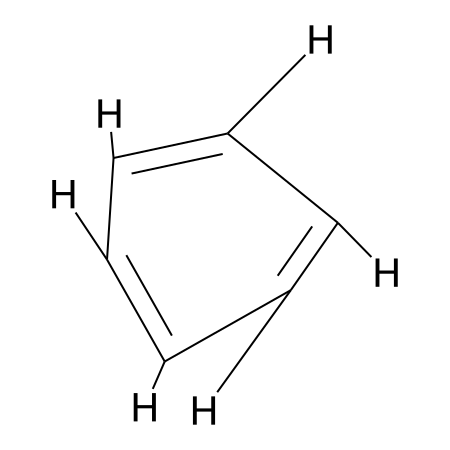

In [ ]:
# Visualização 2D da molécula final
Draw.MolToImage(result["mol"], size=(450, 450))


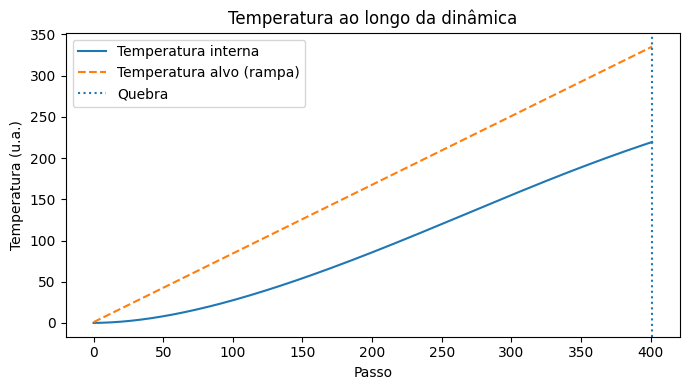

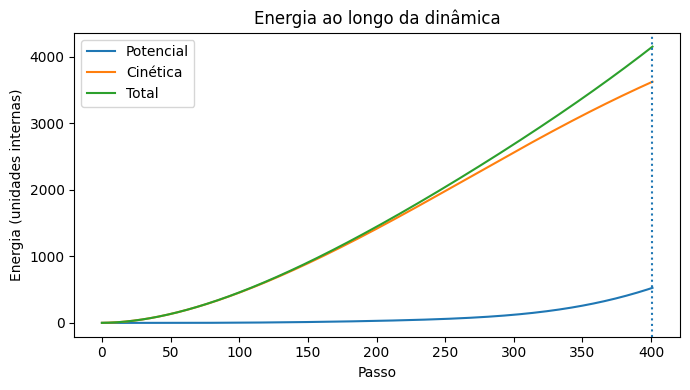

In [ ]:
# =========================
# Gráficos da simulação
# =========================
steps = np.arange(len(result["temperatures"]))

plt.figure(figsize=(7, 4))
plt.plot(steps, result["temperatures"], label="Temperatura interna")
plt.plot(steps, result["target_temperatures"], "--", label="Temperatura alvo (rampa)")
if result["break_step"] is not None:
    plt.axvline(result["break_step"], linestyle=":", label="Quebra")
plt.xlabel("Passo")
plt.ylabel("Temperatura (u.a.)")
plt.title("Temperatura ao longo da dinâmica")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(steps, result["potential_energies"], label="Potencial")
plt.plot(steps, result["kinetic_energies"], label="Cinética")
plt.plot(steps, result["total_energies"], label="Total")
if result["break_step"] is not None:
    plt.axvline(result["break_step"], linestyle=":")
plt.xlabel("Passo")
plt.ylabel("Energia (unidades internas)")
plt.title("Energia ao longo da dinâmica")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# =========================
# Relatório das ligações no frame final
# =========================
final_pos = result["trajectory"][-1]
for bond_index, (i, j, r0, k) in enumerate(result["bonds"]):
    distance = np.linalg.norm(final_pos[i] - final_pos[j])
    threshold = break_factor * (result["radii"][i] + result["radii"][j])
    flag = "QUEBROU" if distance > threshold else "ok"
    print(
        f"{bond_index:02d} | {result['symbols'][i]}-{result['symbols'][j]} | "
        f"d0 = {r0:.2f} Å | d = {distance:.2f} Å | limite = {threshold:.2f} Å | {flag}"
    )


00 | C-C | d0 = 1.40 Å | d = 1.47 Å | limite = 3.04 Å | ok
01 | C-C | d0 = 1.40 Å | d = 1.29 Å | limite = 3.04 Å | ok
02 | C-C | d0 = 1.40 Å | d = 1.50 Å | limite = 3.04 Å | ok
03 | C-C | d0 = 1.40 Å | d = 1.88 Å | limite = 3.04 Å | ok
04 | C-C | d0 = 1.40 Å | d = 1.12 Å | limite = 3.04 Å | ok
05 | C-C | d0 = 1.40 Å | d = 1.88 Å | limite = 3.04 Å | ok
06 | C-H | d0 = 1.08 Å | d = 2.28 Å | limite = 2.14 Å | QUEBROU
07 | C-H | d0 = 1.08 Å | d = 1.35 Å | limite = 2.14 Å | ok
08 | C-H | d0 = 1.08 Å | d = 1.41 Å | limite = 2.14 Å | ok
09 | C-H | d0 = 1.08 Å | d = 1.70 Å | limite = 2.14 Å | ok
10 | C-H | d0 = 1.08 Å | d = 1.24 Å | limite = 2.14 Å | ok
11 | C-H | d0 = 1.08 Å | d = 1.88 Å | limite = 2.14 Å | ok


In [ ]:
# =========================
# Animação da trajetória
# =========================
def animate_trajectory(result, interval=120, figsize=(6, 6)):
    frames = result["trajectory"]
    bonds = result["bonds"]
    symbols = result["symbols"]
    saved_steps = result["saved_steps"]

    coords_all = np.concatenate(frames, axis=0)
    xyz_min = coords_all.min(axis=0)
    xyz_max = coords_all.max(axis=0)
    center = 0.5 * (xyz_min + xyz_max)
    span = (xyz_max - xyz_min).max()
    pad = 0.25 * span + 0.5

    fig, ax = plt.subplots(figsize=figsize)

    def draw_frame(frame_index):
        ax.clear()
        pos = frames[frame_index]

        # desenha ligações que ainda estejam abaixo do limiar de quebra
        for i, j, r0, k in bonds:
            distance = np.linalg.norm(pos[i] - pos[j])
            threshold = break_factor * (result["radii"][i] + result["radii"][j])
            if distance <= threshold:
                ax.plot(
                    [pos[i, 0], pos[j, 0]],
                    [pos[i, 1], pos[j, 1]],
                    linewidth=2,
                )

        for idx, sym in enumerate(symbols):
            ax.scatter(
                pos[idx, 0], pos[idx, 1],
                s=ATOM_SIZE_MAP.get(sym, 140),
                c=ATOM_COLOR_MAP.get(sym, "gray"),
                edgecolors="white",
                linewidths=0.8,
                zorder=3
            )
            ax.text(pos[idx, 0], pos[idx, 1], sym, ha="center", va="center", fontsize=8, zorder=4)

        ax.set_aspect("equal")
        ax.set_xlim(center[0] - span / 2 - pad, center[0] + span / 2 + pad)
        ax.set_ylim(center[1] - span / 2 - pad, center[1] + span / 2 + pad)

        step = int(saved_steps[frame_index])
        title = f"Frame {frame_index + 1}/{len(frames)} | passo {step}"
        if step > 0:
            idx = min(step - 1, len(result["target_temperatures"]) - 1)
            title += f" | T alvo ≈ {result['target_temperatures'][idx]:.1f} K"
        if result["break_step"] is not None and step >= result["break_step"]:
            title += " | QUEBRA"
        ax.set_title(title)
        ax.set_xlabel("x (Å)")
        ax.set_ylabel("y (Å)")
        ax.grid(alpha=0.2)

    anim = FuncAnimation(fig, draw_frame, frames=len(frames), interval=interval, repeat=False)
    plt.close(fig)
    return HTML(anim.to_jshtml())

display(animate_trajectory(result))
